In [48]:
# Fencing Rating Analysis
# Analyze tournament participation patterns for fencers achieving ratings E, D, C, B, A from U status

import pandas as pd
import re
from datetime import datetime
from collections import defaultdict
import numpy as np


In [49]:
# Step 1: Load all three CSV files with error handling

def load_csv_with_errors(filename):
    """Load CSV file with error handling for malformed rows."""
    try:
        df = pd.read_csv(filename)
        print(f"{filename} loaded successfully!")
        return df
    except pd.errors.ParserError as e:
        print(f"Parser error encountered in {filename}: {e}")
        print("Attempting to read with error handling...")
        df = pd.read_csv(filename, on_bad_lines='skip')
        print(f"Loaded {len(df)} rows (some malformed rows were skipped)")
        return df

# Load all three CSV files
epee_df = load_csv_with_errors('EpeeResults.csv')
foil_df = load_csv_with_errors('FoilResults.csv')
saber_df = load_csv_with_errors('SaberResults.csv')

print(f"\nEpee: {len(epee_df)} rows")
print(f"Foil: {len(foil_df)} rows")
print(f"Saber: {len(saber_df)} rows")


EpeeResults.csv loaded successfully!
Parser error encountered in FoilResults.csv: Error tokenizing data. C error: Expected 15 fields in line 113670, saw 16

Attempting to read with error handling...
Loaded 227506 rows (some malformed rows were skipped)
SaberResults.csv loaded successfully!

Epee: 241476 rows
Foil: 227506 rows
Saber: 65608 rows


In [50]:
# Step 2: Helper Functions

def extract_rating_letter(rating_str):
    """Extract the letter part from weaponRating or earned (U, E, D, C, B, A).
    Handles 'Unrated' as 'U'.
    """
    if pd.isna(rating_str) or not isinstance(rating_str, str):
        return None
    
    rating_str = str(rating_str).strip()
    
    # Handle "Unrated" explicitly
    if rating_str.upper() == 'UNRATED' or rating_str == 'U':
        return 'U'
    
    # Match standard format: letter followed by digits (e.g., E21, D22)
    m = re.match(r'^([UEDCBA])\d*$', rating_str)
    if m:
        return m.group(1)
    
    return None

def normalize_classification(class_str):
    """Extract first classification from combined values (e.g., 'A2/B3' -> 'A2').
    Also handles 'Unrated' -> 'U'.
    """
    if pd.isna(class_str) or not isinstance(class_str, str):
        return None
    # Split by '/' and take the first part
    parts = str(class_str).split('/')
    first_part = parts[0].strip() if parts else None
    
    # Handle "Unrated" -> "U"
    if first_part and first_part.upper() == 'UNRATED':
        return 'U'
    
    return first_part

def prepare_dataframe(df, weapon_name):
    """Prepare and clean a dataframe for analysis."""
    df = df.copy()
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    
    # Handle null club names - replace with empty string for grouping
    df['club1Name'] = df['club1Name'].fillna('')
    
    # Normalize name and club fields (strip whitespace)
    df['name'] = df['name'].astype(str).str.strip()
    df['club1Name'] = df['club1Name'].astype(str).str.strip()
    
    # Normalize classifications
    df['classification'] = df['classification'].apply(normalize_classification)
    
    # Extract rating letters
    df['rating_letter'] = df['weaponRating'].apply(extract_rating_letter)
    df['earned_letter'] = df['earned'].apply(extract_rating_letter)
    
    # Add weapon name if not present
    if 'weapon' not in df.columns or df['weapon'].isna().all():
        df['weapon'] = weapon_name
    
    # Sort by date for chronological analysis
    df = df.sort_values('date').reset_index(drop=True)
    
    return df

# Prepare all dataframes
epee_df = prepare_dataframe(epee_df, 'Epee')
foil_df = prepare_dataframe(foil_df, 'Foil')
saber_df = prepare_dataframe(saber_df, 'Saber')

print("Data preparation complete!")
print(f"Epee: {len(epee_df)} rows, date range: {epee_df['date'].min()} to {epee_df['date'].max()}")
print(f"Foil: {len(foil_df)} rows, date range: {foil_df['date'].min()} to {foil_df['date'].max()}")
print(f"Saber: {len(saber_df)} rows, date range: {saber_df['date'].min()} to {saber_df['date'].max()}")


Data preparation complete!
Epee: 241476 rows, date range: 2021-08-01 00:00:00 to 2025-07-28 00:00:00
Foil: 227506 rows, date range: 2021-08-06 00:00:00 to 2025-07-27 00:00:00
Saber: 65608 rows, date range: 2021-08-13 00:00:00 to 2023-05-21 00:00:00


In [51]:
# Step 3: Build Tournament History Tracker (OPTIMIZED VERSION)

def analyze_rating_progression_optimized(df, weapon, target_rating):
    """
    OPTIMIZED: Analyze rating progression using vectorized operations and groupby.
    This is much faster than iterating through each fencer individually.
    """
    print(f"\nAnalyzing {weapon} - {target_rating} rating...")
    
    # Pre-filter for this weapon only once
    weapon_data = df[df['weapon'] == weapon].copy()
    
    if len(weapon_data) == 0:
        return []
    
    # Sort by name, club, and date for efficient processing
    weapon_data = weapon_data.sort_values(['name', 'club1Name', 'date']).reset_index(drop=True)
    
    # Rating order for comparison
    rating_order = {'U': 0, 'E': 1, 'D': 2, 'C': 3, 'B': 4, 'A': 5}
    target_order = rating_order.get(target_rating, 999)
    
    # Group by fencer (name + club) - this is much faster than iterating
    grouped = weapon_data.groupby(['name', 'club1Name'])
    
    results = []
    total_groups = len(grouped)
    processed = 0
    
    for (name, club), fencer_data in grouped:
        processed += 1
        if processed % 1000 == 0:
            print(f"  Processed {processed}/{total_groups} fencers...")
        
        # Reset index for this group
        fencer_data = fencer_data.reset_index(drop=True)
        
        # Find first U appearance using vectorized operation
        u_mask = fencer_data['rating_letter'] == 'U'
        if not u_mask.any():
            continue
        
        first_u_idx = u_mask.idxmax()  # Get first True index (position in fencer_data)
        
        # Find when target rating was achieved
        # Check earned column first (most reliable) - only look after first U
        earned_mask = (fencer_data['earned_letter'] == target_rating) & (fencer_data.index >= first_u_idx)
        
        target_achieved_idx = None
        
        if earned_mask.any():
            target_achieved_idx = earned_mask.idxmax()  # Get first True index
        else:
            # Check if current rating reached target
            # Only check rows from first_u_idx onwards
            post_u_data = fencer_data.iloc[first_u_idx:].reset_index(drop=True)
            if len(post_u_data) > 0:
                # Get rating orders for comparison
                current_ratings = post_u_data['rating_letter'].apply(
                    lambda x: rating_order.get(x, 999)
                )
                reached_mask = current_ratings >= target_order
                if reached_mask.any():
                    # Get the position relative to post_u_data (0-based in the slice)
                    relative_idx = reached_mask.idxmax()
                    # Convert back to position in original fencer_data
                    target_achieved_idx = first_u_idx + relative_idx
                else:
                    continue
            else:
                continue
        
        # Safety check: ensure target_achieved_idx is valid
        if target_achieved_idx is None or target_achieved_idx < first_u_idx or target_achieved_idx >= len(fencer_data):
            continue
        
        # Extract progression (from first U to target achievement, inclusive)
        progression = fencer_data.iloc[first_u_idx:target_achieved_idx + 1].copy()
        
        # Verify they actually achieved the target
        earned_in_progression = progression[progression['earned_letter'].notna()]['earned_letter'].values
        final_rating_letter = progression.iloc[-1]['rating_letter']
        final_order = rating_order.get(final_rating_letter, 999)
        
        if target_rating not in earned_in_progression and final_order < target_order:
            continue
        
        # Count tournaments
        tournament_count = len(progression)
        
        # Count classifications using value_counts (much faster than iterating)
        all_classifications = ['U', 'E1', 'D1', 'C1', 'C2', 'C3', 'B1', 'B2', 'B3', 'A1', 'A2', 'A3', 'A4']
        classification_counts = {cls: 0 for cls in all_classifications}
        
        # Use value_counts for efficient counting
        class_counts = progression['classification'].value_counts()
        for cls, count in class_counts.items():
            if cls in classification_counts:
                classification_counts[cls] = int(count)
        
        # Get achieved rating
        earned_ratings = progression[progression['earned_letter'].notna()]['earned']
        achieved_rating = earned_ratings.iloc[-1] if len(earned_ratings) > 0 else None
        
        results.append({
            'name': name,
            'club': club,
            'weapon': weapon,
            'rating': achieved_rating,
            'tournament_count': tournament_count,
            'classification_counts': classification_counts
        })
    
    print(f"Found {len(results)} qualifying fencers")
    return results

# Keep old function for backward compatibility but mark as deprecated
def get_fencer_progression(df, name, club, weapon, target_rating):
    """Legacy function - use analyze_rating_progression_optimized instead."""
    # This is kept for reference but won't be used in optimized version
    pass

def find_fencers_for_rating(df, weapon, target_rating):
    """Legacy function - use analyze_rating_progression_optimized instead."""
    # This is kept for reference but won't be used in optimized version
    pass

print("Optimized tournament history tracker functions created!")


Optimized tournament history tracker functions created!


In [52]:
# Step 4: Count Tournaments and Classifications

def count_classifications(tournament_records):
    """
    Count occurrences of each classification type in tournament records.
    Returns dictionary with counts for each classification.
    """
    # Define all possible classifications
    all_classifications = ['U', 'E1', 'D1', 'C1', 'C2', 'C3', 'B1', 'B2', 'B3', 'A1', 'A2', 'A3', 'A4']
    
    # Initialize counts
    counts = {cls: 0 for cls in all_classifications}
    
    # Count classifications from tournament records
    for _, row in tournament_records.iterrows():
        classification = row['classification']
        if pd.notna(classification) and classification in counts:
            counts[classification] += 1
    
    return counts

def analyze_fencer_progression(df, name, club, weapon, target_rating):
    """
    Analyze a single fencer's progression to target rating.
    Returns dictionary with tournament count and classification counts.
    """
    progression = get_fencer_progression(df, name, club, weapon, target_rating)
    
    if progression is None or len(progression) == 0:
        return None
    
    # Count total tournaments
    tournament_count = len(progression)
    
    # Count classifications
    classification_counts = count_classifications(progression)
    
    # Get the rating they achieved
    earned_ratings = progression[progression['earned_letter'].notna()]['earned']
    if len(earned_ratings) > 0:
        achieved_rating = earned_ratings.iloc[-1]  # Last earned rating
    else:
        achieved_rating = None
    
    return {
        'name': name,
        'club': club,
        'weapon': weapon,
        'rating': achieved_rating,
        'tournament_count': tournament_count,
        'classification_counts': classification_counts
    }

print("Classification counting functions created!")


Classification counting functions created!


In [53]:
# Step 5: Main Analysis Function (Uses Optimized Version)

# The optimized function is now the main one - it does everything in one pass
# Test the optimized analysis on a small sample
print("Testing optimized analysis functions...")
test_results = analyze_rating_progression_optimized(epee_df, 'Epee', 'E')
print(f"Sample: Found {len(test_results)} fencers for Epee E rating")
if len(test_results) > 0:
    print(f"Example: {test_results[0]['name']} from {test_results[0]['club']}")
    print(f"  Tournaments: {test_results[0]['tournament_count']}")
    print(f"  Classifications: {dict(list(test_results[0]['classification_counts'].items())[:5])}")


Testing optimized analysis functions...

Analyzing Epee - E rating...
  Processed 1000/31707 fencers...
  Processed 2000/31707 fencers...
  Processed 3000/31707 fencers...
  Processed 4000/31707 fencers...
  Processed 5000/31707 fencers...
  Processed 6000/31707 fencers...
  Processed 7000/31707 fencers...
  Processed 8000/31707 fencers...
  Processed 9000/31707 fencers...
  Processed 10000/31707 fencers...
  Processed 11000/31707 fencers...
  Processed 12000/31707 fencers...
  Processed 13000/31707 fencers...
  Processed 14000/31707 fencers...
  Processed 15000/31707 fencers...
  Processed 16000/31707 fencers...
  Processed 17000/31707 fencers...
  Processed 18000/31707 fencers...
  Processed 19000/31707 fencers...
  Processed 20000/31707 fencers...
  Processed 21000/31707 fencers...
  Processed 22000/31707 fencers...
  Processed 23000/31707 fencers...
  Processed 24000/31707 fencers...
  Processed 25000/31707 fencers...
  Processed 26000/31707 fencers...
  Processed 27000/31707 fence

In [64]:
# Step 6: Calculate Averages

def calculate_averages(fencer_results):
    """
    Calculate average tournament count and average classification counts
    across all fencer results.
    """
    if len(fencer_results) == 0:
        return None
    
    # Calculate average tournament count
    tournament_counts = [r['tournament_count'] for r in fencer_results]
    avg_tournaments = np.mean(tournament_counts)
    
    # Calculate average classification counts
    all_classifications = ['U', 'E1', 'D1', 'C1', 'C2', 'C3', 'B1', 'B2', 'B3', 'A1', 'A2', 'A3', 'A4']
    avg_classifications = {}
    
    for cls in all_classifications:
        counts = [r['classification_counts'].get(cls, 0) for r in fencer_results]
        avg_classifications[cls] = np.mean(counts)
    
    return {
        'avg_tournaments': avg_tournaments,
        'avg_classifications': avg_classifications,
        'fencer_count': len(fencer_results)
    }

# Test average calculation
if len(test_results) > 0:
    test_avg = calculate_averages(test_results)
    print(f"\nTest averages for Epee E rating:")
    print(f"  Average tournaments: {test_avg['avg_tournaments']:.2f}")
    print(f"  Fencer count: {test_avg['fencer_count']}")
    print(f"  Sample classifications: {dict(list(test_avg['avg_classifications'].items())[:13])}")



Test averages for Epee E rating:
  Average tournaments: 10.33
  Fencer count: 3783
  Sample classifications: {'U': 3.543219666931007, 'E1': 0.9804388051810732, 'D1': 0.5604017975151996, 'C1': 0.36082474226804123, 'C2': 1.2437219138250066, 'C3': 0.09965635738831616, 'B1': 0.1612476870208829, 'B2': 1.1667988369019298, 'B3': 0.14274385408406026, 'A1': 0.09965635738831616, 'A2': 1.1792228390166535, 'A3': 0.17208564631245044, 'A4': 0.6212001057361882}


In [55]:
# Step 7: Run Complete Analysis for All Weapons and Ratings (OPTIMIZED)

def run_complete_analysis():
    """
    Run the complete analysis for all weapons and all target ratings.
    Uses optimized functions for much faster processing.
    Returns:
        - results: nested dictionary with averages: results[weapon][rating] = {avg_tournaments, avg_classifications}
        - individual_data: nested dictionary with individual fencer results: individual_data[weapon][rating] = [list of fencer results]
    """
    all_dataframes = {
        'Epee': epee_df,
        'Foil': foil_df,
        'Saber': saber_df
    }
    
    target_ratings = ['E', 'D', 'C', 'B', 'A']
    results = {}
    individual_data = {}  # Store individual fencer results for box plots
    
    for weapon, df in all_dataframes.items():
        results[weapon] = {}
        individual_data[weapon] = {}
        print(f"\n{'='*60}")
        print(f"Processing {weapon}")
        print(f"{'='*60}")
        
        for rating in target_ratings:
            # Get fencer results using optimized function
            fencer_results = analyze_rating_progression_optimized(df, weapon, rating)
            
            # Store individual results for box plots
            individual_data[weapon][rating] = fencer_results
            
            # Calculate averages
            if len(fencer_results) > 0:
                avg_data = calculate_averages(fencer_results)
                results[weapon][rating] = avg_data
                print(f"{weapon} {rating}: {avg_data['fencer_count']} fencers, "
                      f"avg {avg_data['avg_tournaments']:.1f} tournaments")
            else:
                results[weapon][rating] = None
                print(f"{weapon} {rating}: No qualifying fencers found")
    
    return results, individual_data

# Run the complete analysis (should be much faster now!)
print("\n" + "="*80)
print("STARTING COMPLETE ANALYSIS (OPTIMIZED)")
print("="*80)
complete_results, individual_fencer_data = run_complete_analysis()



STARTING COMPLETE ANALYSIS (OPTIMIZED)

Processing Epee

Analyzing Epee - E rating...
  Processed 1000/31707 fencers...
  Processed 2000/31707 fencers...
  Processed 3000/31707 fencers...
  Processed 4000/31707 fencers...
  Processed 5000/31707 fencers...
  Processed 6000/31707 fencers...
  Processed 7000/31707 fencers...
  Processed 8000/31707 fencers...
  Processed 9000/31707 fencers...
  Processed 10000/31707 fencers...
  Processed 11000/31707 fencers...
  Processed 12000/31707 fencers...
  Processed 13000/31707 fencers...
  Processed 14000/31707 fencers...
  Processed 15000/31707 fencers...
  Processed 16000/31707 fencers...
  Processed 17000/31707 fencers...
  Processed 18000/31707 fencers...
  Processed 19000/31707 fencers...
  Processed 20000/31707 fencers...
  Processed 21000/31707 fencers...
  Processed 22000/31707 fencers...
  Processed 23000/31707 fencers...
  Processed 24000/31707 fencers...
  Processed 25000/31707 fencers...
  Processed 26000/31707 fencers...
  Processed 

In [56]:
# Step 8: Generate Summary Tables

def generate_summary_table(results, weapon):
    """
    Generate a summary table for a specific weapon.
    Returns a DataFrame matching the format in end_goal.md
    """
    target_ratings = ['E', 'D', 'C', 'B', 'A']
    table_data = []
    
    for rating in target_ratings:
        if results[weapon][rating] is not None:
            avg_data = results[weapon][rating]
            row = {
                'weapon': weapon,
                'rating': rating,
                'average_tournaments': round(avg_data['avg_tournaments'], 1),
                'composition': avg_data['avg_classifications']
            }
            table_data.append(row)
    
    return pd.DataFrame(table_data)

# Generate all three summary tables
epee_table = generate_summary_table(complete_results, 'Epee')
foil_table = generate_summary_table(complete_results, 'Foil')
saber_table = generate_summary_table(complete_results, 'Saber')

print("\n" + "="*80)
print("TABLE 1: EPEE")
print("="*80)
print(epee_table.to_string(index=False))

print("\n" + "="*80)
print("TABLE 2: FOIL")
print("="*80)
print(foil_table.to_string(index=False))

print("\n" + "="*80)
print("TABLE 3: SABER")
print("="*80)
print(saber_table.to_string(index=False))



TABLE 1: EPEE
weapon rating  average_tournaments                                                                                                                                                                                                                                                                                                                                           composition
  Epee      E                 10.3 {'U': 3.543219666931007, 'E1': 0.9804388051810732, 'D1': 0.5604017975151996, 'C1': 0.36082474226804123, 'C2': 1.2437219138250066, 'C3': 0.09965635738831616, 'B1': 0.1612476870208829, 'B2': 1.1667988369019298, 'B3': 0.14274385408406026, 'A1': 0.09965635738831616, 'A2': 1.1792228390166535, 'A3': 0.17208564631245044, 'A4': 0.6212001057361882}
  Epee      D                 15.5       {'U': 4.42603550295858, 'E1': 0.9745106964041875, 'D1': 0.706417842512517, 'C1': 0.5466545289030497, 'C2': 1.896222121074192, 'C3': 0.19344560764679108, 'B1': 0.270368684569868, 'B2': 2.0227

In [57]:
# Step 10: Create Box Plots for Tournament Counts by Rating
# Uses data from Step 7 (no redundant analysis)

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

def extract_tournament_data_from_step7(individual_fencer_data):
    """
    Extract tournament count data from the individual_fencer_data collected in Step 7.
    Returns nested dictionary: data[weapon][rating] = [list of tournament counts]
    """
    target_ratings = ['E', 'D', 'C', 'B', 'A']
    tournament_data = {}
    
    print("Extracting tournament count data from Step 7 results...")
    
    for weapon in ['Epee', 'Foil', 'Saber']:
        tournament_data[weapon] = {}
        print(f"\n{weapon}:")
        
        for rating in target_ratings:
            if weapon in individual_fencer_data and rating in individual_fencer_data[weapon]:
                fencer_results = individual_fencer_data[weapon][rating]
                # Extract tournament counts
                tournament_counts = [r['tournament_count'] for r in fencer_results]
                tournament_data[weapon][rating] = tournament_counts
                print(f"  {rating}: {len(tournament_counts)} fencers")
            else:
                tournament_data[weapon][rating] = []
                print(f"  {rating}: 0 fencers")
    
    return tournament_data

# Extract the data from Step 7 (no redundant analysis!)
print("="*80)
print("EXTRACTING DATA FOR BOX PLOTS FROM STEP 7")
print("="*80)
boxplot_data = extract_tournament_data_from_step7(individual_fencer_data)


EXTRACTING DATA FOR BOX PLOTS FROM STEP 7
Extracting tournament count data from Step 7 results...

Epee:
  E: 3783 fencers
  D: 2197 fencers
  C: 1368 fencers
  B: 628 fencers
  A: 243 fencers

Foil:
  E: 2829 fencers
  D: 1274 fencers
  C: 636 fencers
  B: 267 fencers
  A: 106 fencers

Saber:
  E: 854 fencers
  D: 336 fencers
  C: 144 fencers
  B: 40 fencers
  A: 9 fencers



CREATING BOX PLOTS
Note: Box plots show:
  - Box: Interquartile Range (IQR) - 25th to 75th percentile
  - Line in box: Median
  - Dashed line: Mean
  - Whiskers: Low (min) and High (max) values


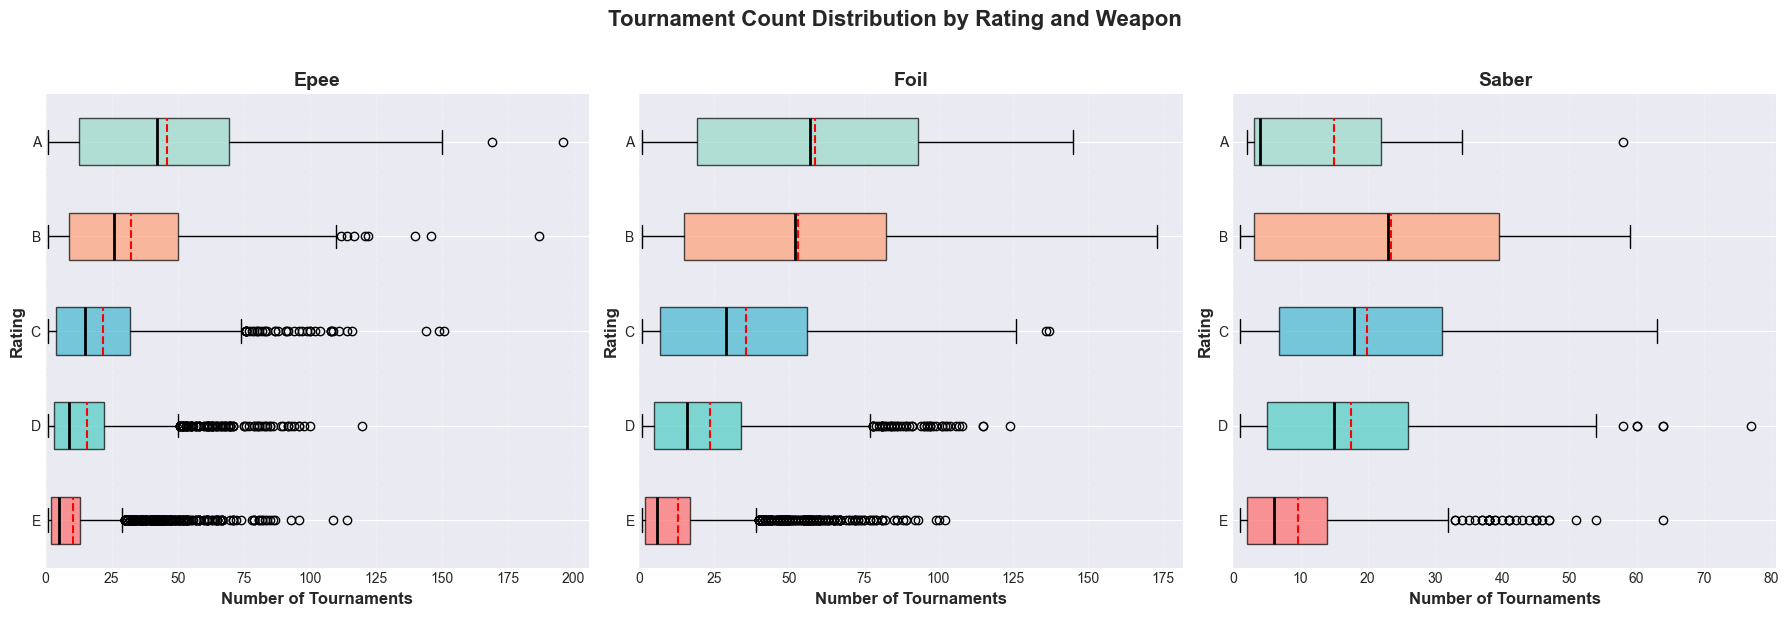

In [58]:
# Create the box plots

def create_boxplots(tournament_data):
    """
    Create box plots for each weapon showing tournament count distributions by rating.
    Y-axis: Rating (E, D, C, B, A)
    X-axis: Number of tournaments
    Shows: low (whisker), IQR (box), high (whisker), median (line), mean (dashed line)
    """
    weapons = ['Epee', 'Foil', 'Saber']
    ratings = ['E', 'D', 'C', 'B', 'A']
    
    # Create figure with 3 subplots (one for each weapon)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Tournament Count Distribution by Rating and Weapon', fontsize=16, fontweight='bold', y=1.02)
    
    for idx, weapon in enumerate(weapons):
        ax = axes[idx]
        
        # Prepare data for this weapon
        plot_data = []
        plot_labels = []
        
        for rating in ratings:
            if weapon in tournament_data and rating in tournament_data[weapon]:
                counts = tournament_data[weapon][rating]
                if len(counts) > 0:
                    plot_data.append(counts)
                    plot_labels.append(rating)
        
        # Create box plot (horizontal: ratings on y-axis, tournament counts on x-axis)
        if plot_data:
            bp = ax.boxplot(plot_data, labels=plot_labels, vert=False, patch_artist=True,
                           showmeans=True, meanline=True, 
                           boxprops=dict(alpha=0.7),
                           medianprops=dict(color='black', linewidth=2),
                           meanprops=dict(linestyle='--', linewidth=1.5, color='red'))
            
            # Color the boxes with different colors for each rating
            colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            
            # Customize the plot (swapped axes for horizontal plot)
            ax.set_xlabel('Number of Tournaments', fontsize=12, fontweight='bold')
            ax.set_ylabel('Rating', fontsize=12, fontweight='bold')
            ax.set_title(f'{weapon}', fontsize=14, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='x', linestyle='--')
            
            # Set x-axis to start at 0 for better visualization
            ax.set_xlim(left=0)
            
            # Ratings will appear in order: E (bottom), D, C, B, A (top)
            # This shows natural progression from lower to higher ratings
        else:
            ax.text(0.5, 0.5, 'No data available', 
                   transform=ax.transAxes, ha='center', va='center', fontsize=12)
            ax.set_title(f'{weapon}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create and display the box plots
print("\n" + "="*80)
print("CREATING BOX PLOTS")
print("="*80)
print("Note: Box plots show:")
print("  - Box: Interquartile Range (IQR) - 25th to 75th percentile")
print("  - Line in box: Median")
print("  - Dashed line: Mean")
print("  - Whiskers: Low (min) and High (max) values")
print("="*80)
create_boxplots(boxplot_data)



CREATING PIE CHARTS FOR EVENT CLASSIFICATION COMPOSITION
Each weapon will have 5 pie charts (one for each rating: E, D, C, B, A)
Each pie chart shows the distribution of tournament event classifications


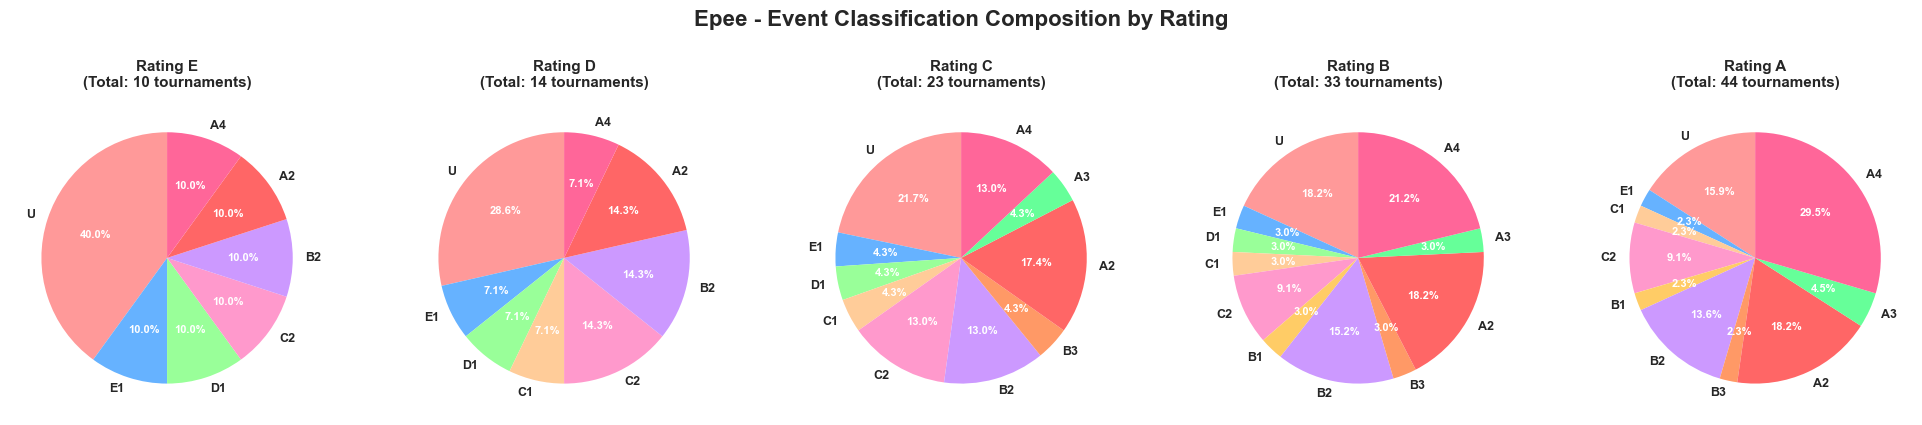

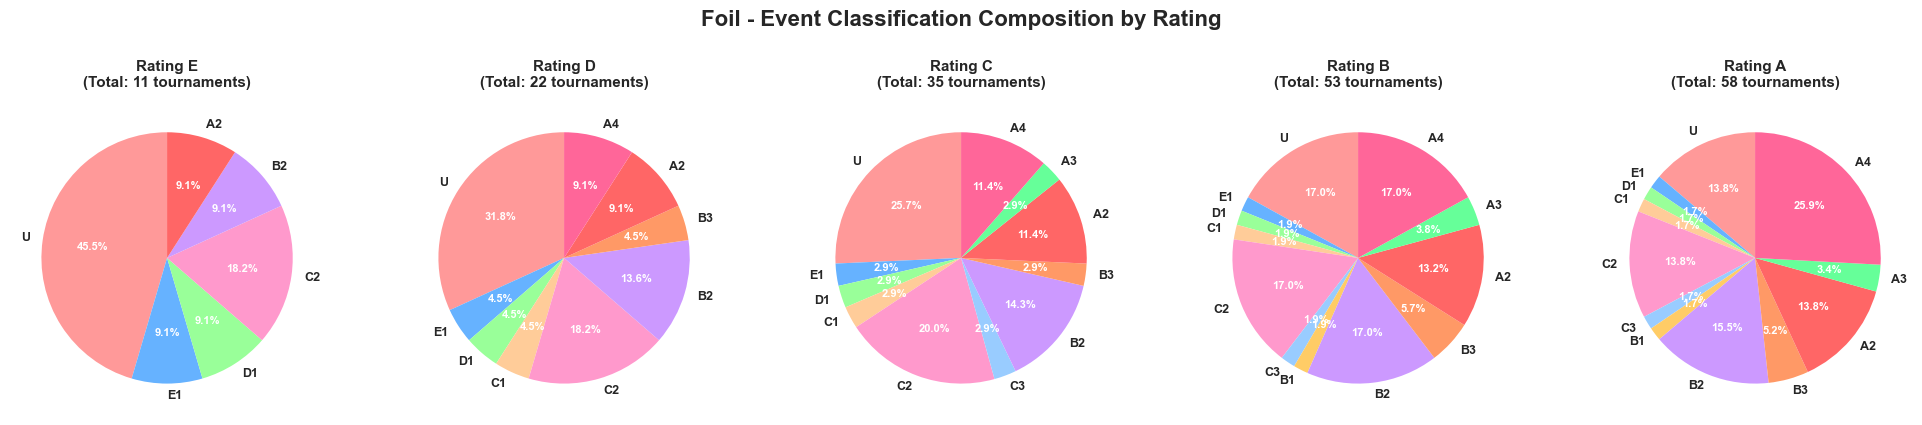

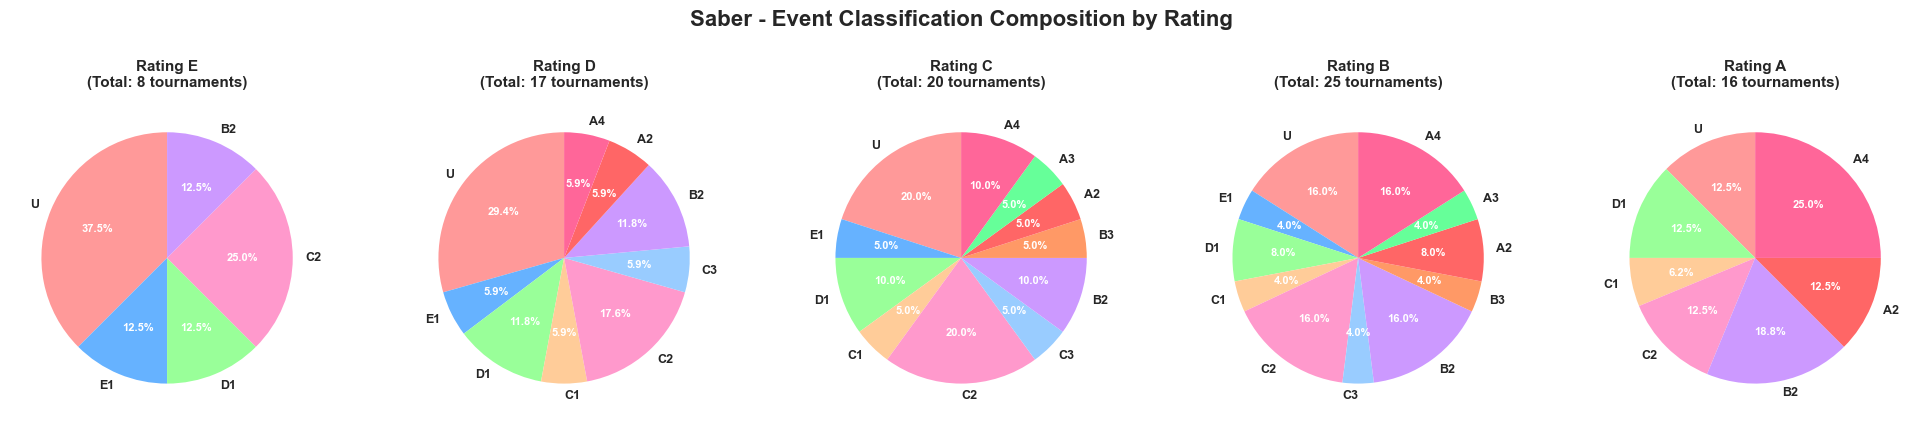

In [65]:
# Step 11: Create Pie Charts for Event Classification Composition
# Creates 15 pie charts total: 3 weapons × 5 ratings (E, D, C, B, A)

def create_pie_charts_for_classifications():
    """
    Create pie charts showing the composition of event classifications for each weapon and rating.
    Uses data from the summary tables (epee_table, foil_table, saber_table).
    """
    weapons = {
        'Epee': epee_table,
        'Foil': foil_table,
        'Saber': saber_table
    }
    
    ratings = ['E', 'D', 'C', 'B', 'A']
    
    # Define colors for each classification type
    classification_colors = {
        'U': '#FF9999',
        'E1': '#66B2FF',
        'D1': '#99FF99',
        'C1': '#FFCC99',
        'C2': '#FF99CC',
        'C3': '#99CCFF',
        'B1': '#FFCC66',
        'B2': '#CC99FF',
        'B3': '#FF9966',
        'A1': '#99FFCC',
        'A2': '#FF6666',
        'A3': '#66FF99',
        'A4': '#FF6699'
    }
    
    # Create a figure with subplots for each weapon
    for weapon_name, table in weapons.items():
        # Create figure with 5 subplots (one for each rating)
        fig, axes = plt.subplots(1, 5, figsize=(20, 4))
        fig.suptitle(f'{weapon_name} - Event Classification Composition by Rating', 
                     fontsize=16, fontweight='bold', y=1.05)
        
        for idx, rating in enumerate(ratings):
            ax = axes[idx]
            
            # Get the row for this rating
            rating_row = table[table['rating'] == rating]
            
            if len(rating_row) > 0:
                # Get the composition dictionary
                comp_dict = rating_row.iloc[0]['composition']
                
                # Format the composition (round to integers)
                formatted_comp = format_composition_dict(comp_dict)
                
                # Filter out zero values for cleaner pie chart
                filtered_comp = {k: v for k, v in formatted_comp.items() if v > 0}
                
                if len(filtered_comp) > 0:
                    # Prepare data for pie chart
                    labels = list(filtered_comp.keys())
                    sizes = list(filtered_comp.values())
                    colors_list = [classification_colors.get(label, '#CCCCCC') for label in labels]
                    
                    # Create pie chart
                    wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_list,
                                                     autopct='%1.1f%%', startangle=90,
                                                     textprops={'fontsize': 9, 'fontweight': 'bold'})
                    
                    # Make percentage text smaller and bold
                    for autotext in autotexts:
                        autotext.set_color('white')
                        autotext.set_fontweight('bold')
                        autotext.set_fontsize(8)
                    
                    ax.set_title(f'Rating {rating}\n(Total: {sum(sizes)} tournaments)', 
                               fontsize=11, fontweight='bold', pad=10)
                else:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                           transform=ax.transAxes, fontsize=12)
                    ax.set_title(f'Rating {rating}', fontsize=11, fontweight='bold')
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=12)
                ax.set_title(f'Rating {rating}', fontsize=11, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        print()  # Add spacing between weapon groups

# Create all pie charts
print("\n" + "="*80)
print("CREATING PIE CHARTS FOR EVENT CLASSIFICATION COMPOSITION")
print("="*80)
print("Each weapon will have 5 pie charts (one for each rating: E, D, C, B, A)")
print("Each pie chart shows the distribution of tournament event classifications")
print("="*80)
create_pie_charts_for_classifications()


In [59]:
# Format output to match end_goal.md format exactly

def format_composition_dict(comp_dict):
    """Format classification composition dictionary as string."""
    # Round values to integers for display
    formatted = {k: int(round(v)) for k, v in comp_dict.items()}
    return formatted

print("\n" + "="*80)
print("FINAL SUMMARY TABLES (Formatted)")
print("="*80)

print("\n(TABLE 1)")
print("weapon | rating | average tournaments | composition of tournament event classifications")
for _, row in epee_table.iterrows():
    comp = format_composition_dict(row['composition'])
    print(f"{row['weapon']} | {row['rating']} | {row['average_tournaments']:.0f} | {comp}")

print("\n(TABLE 2)")
print("weapon | rating | average tournaments | composition of tournament event classifications")
for _, row in foil_table.iterrows():
    comp = format_composition_dict(row['composition'])
    print(f"{row['weapon']} | {row['rating']} | {row['average_tournaments']:.0f} | {comp}")

print("\n(TABLE 3)")
print("weapon | rating | average tournaments | composition of tournament event classifications")
for _, row in saber_table.iterrows():
    comp = format_composition_dict(row['composition'])
    print(f"{row['weapon']} | {row['rating']} | {row['average_tournaments']:.0f} | {comp}")



FINAL SUMMARY TABLES (Formatted)

(TABLE 1)
weapon | rating | average tournaments | composition of tournament event classifications
Epee | E | 10 | {'U': 4, 'E1': 1, 'D1': 1, 'C1': 0, 'C2': 1, 'C3': 0, 'B1': 0, 'B2': 1, 'B3': 0, 'A1': 0, 'A2': 1, 'A3': 0, 'A4': 1}
Epee | D | 16 | {'U': 4, 'E1': 1, 'D1': 1, 'C1': 1, 'C2': 2, 'C3': 0, 'B1': 0, 'B2': 2, 'B3': 0, 'A1': 0, 'A2': 2, 'A3': 0, 'A4': 1}
Epee | C | 22 | {'U': 5, 'E1': 1, 'D1': 1, 'C1': 1, 'C2': 3, 'C3': 0, 'B1': 0, 'B2': 3, 'B3': 1, 'A1': 0, 'A2': 4, 'A3': 1, 'A4': 3}
Epee | B | 32 | {'U': 6, 'E1': 1, 'D1': 1, 'C1': 1, 'C2': 3, 'C3': 0, 'B1': 1, 'B2': 5, 'B3': 1, 'A1': 0, 'A2': 6, 'A3': 1, 'A4': 7}
Epee | A | 46 | {'U': 7, 'E1': 1, 'D1': 0, 'C1': 1, 'C2': 4, 'C3': 0, 'B1': 1, 'B2': 6, 'B3': 1, 'A1': 0, 'A2': 8, 'A3': 2, 'A4': 13}

(TABLE 2)
weapon | rating | average tournaments | composition of tournament event classifications
Foil | E | 13 | {'U': 5, 'E1': 1, 'D1': 1, 'C1': 0, 'C2': 2, 'C3': 0, 'B1': 0, 'B2': 1, 'B3': 0, 'A1':

In [60]:
# Optional: Generate detailed tables for individual fencers (like TABLE 4 in end_goal.md)

def generate_detailed_fencer_table(df, weapon, target_rating, max_display=10):
    """
    Generate detailed table showing individual fencer data for a weapon and rating.
    Similar to TABLE 4 in end_goal.md
    Uses optimized function for faster processing.
    """
    fencer_results = analyze_rating_progression_optimized(df, weapon, target_rating)
    
    if len(fencer_results) == 0:
        return None
    
    # Create DataFrame
    detailed_data = []
    for result in fencer_results[:max_display]:
        comp = format_composition_dict(result['classification_counts'])
        detailed_data.append({
            'name': result['name'],
            'club': result['club'],
            'weapon': result['weapon'],
            'rating': result['rating'],
            'tournament_count': result['tournament_count'],
            'classification_count': comp
        })
    
    return pd.DataFrame(detailed_data)

# Example: Generate detailed table for Epee E rating
print("\n" + "="*80)
print("DETAILED FENCER TABLE EXAMPLE: Epee E Rating")
print("="*80)
detailed_epee_e = generate_detailed_fencer_table(epee_df, 'Epee', 'E', max_display=5)
if detailed_epee_e is not None:
    print(detailed_epee_e.to_string(index=False))



DETAILED FENCER TABLE EXAMPLE: Epee E Rating

Analyzing Epee - E rating...
  Processed 1000/31707 fencers...
  Processed 2000/31707 fencers...
  Processed 3000/31707 fencers...
  Processed 4000/31707 fencers...
  Processed 5000/31707 fencers...
  Processed 6000/31707 fencers...
  Processed 7000/31707 fencers...
  Processed 8000/31707 fencers...
  Processed 9000/31707 fencers...
  Processed 10000/31707 fencers...
  Processed 11000/31707 fencers...
  Processed 12000/31707 fencers...
  Processed 13000/31707 fencers...
  Processed 14000/31707 fencers...
  Processed 15000/31707 fencers...
  Processed 16000/31707 fencers...
  Processed 17000/31707 fencers...
  Processed 18000/31707 fencers...
  Processed 19000/31707 fencers...
  Processed 20000/31707 fencers...
  Processed 21000/31707 fencers...
  Processed 22000/31707 fencers...
  Processed 23000/31707 fencers...
  Processed 24000/31707 fencers...
  Processed 25000/31707 fencers...
  Processed 26000/31707 fencers...
  Processed 27000/31707

In [61]:
# Step 9: Validation and Edge Case Handling

def validate_results(results):
    """Validate the analysis results and check for data quality issues."""
    print("\n" + "="*80)
    print("VALIDATION AND DATA QUALITY CHECKS")
    print("="*80)
    
    all_weapons = ['Epee', 'Foil', 'Saber']
    all_ratings = ['E', 'D', 'C', 'B', 'A']
    
    for weapon in all_weapons:
        print(f"\n{weapon}:")
        for rating in all_ratings:
            if results[weapon][rating] is not None:
                data = results[weapon][rating]
                print(f"  {rating}: {data['fencer_count']} fencers, "
                      f"avg {data['avg_tournaments']:.2f} tournaments")
                
                # Check for reasonable values
                if data['avg_tournaments'] < 1:
                    print(f"    WARNING: Average tournaments is less than 1")
                if data['avg_tournaments'] > 200:
                    print(f"    WARNING: Average tournaments is unusually high (>200)")
                
                # Check classification distribution
                total_classifications = sum(data['avg_classifications'].values())
                if total_classifications == 0:
                    print(f"    WARNING: No classifications found")
                elif abs(total_classifications - data['avg_tournaments']) > 5:
                    print(f"    WARNING: Classification count ({total_classifications:.1f}) "
                          f"differs significantly from tournament count ({data['avg_tournaments']:.1f})")
            else:
                print(f"  {rating}: No data available")
    
    print("\nValidation complete!")

# Run validation
validate_results(complete_results)



VALIDATION AND DATA QUALITY CHECKS

Epee:
  E: 3783 fencers, avg 10.33 tournaments
  D: 2197 fencers, avg 15.48 tournaments
  C: 1368 fencers, avg 21.69 tournaments
  B: 628 fencers, avg 32.45 tournaments
  A: 243 fencers, avg 46.16 tournaments

Foil:
  E: 2829 fencers, avg 12.93 tournaments
  D: 1274 fencers, avg 23.57 tournaments
  C: 636 fencers, avg 35.76 tournaments
  B: 267 fencers, avg 52.98 tournaments
  A: 106 fencers, avg 58.55 tournaments

Saber:
  E: 854 fencers, avg 9.65 tournaments
  D: 336 fencers, avg 17.51 tournaments
  C: 144 fencers, avg 19.90 tournaments
  B: 40 fencers, avg 23.43 tournaments
  A: 9 fencers, avg 15.00 tournaments

Validation complete!
